# Цена ожидания: быстрый ML против медленного hard-подтверждения

Это отдельный продуктовый эксперимент для ответа на развилку из кейса: отправить
ML-сигнал сразу или ждать подтверждения более медленного hard-индикатора.
Он не участвует в выборе или оценке финальной ML-модели.

На причинном OOT-потоке 2025–2026 сравниваются две фиксированные политики:

1. **Отправить сразу** — использовать дату $T_f$, в которую ML-сигнал уже
   прошёл коммуникационные ограничения.
2. **Ждать подтверждение** — не более пяти опубликованных дат ждать первого
   OOT-срабатывания `momentum`, `low level` или `corridor exit down`. Если его
   нет, сообщение не отправляется. Одно hard-срабатывание подтверждает не более
   одного ML-эпизода.

Для подтверждённых эпизодов цена ожидания равна

$$
waiting\_cost_{bps}=
\left(\frac{P_{T_s}}{P_{T_f}}-1\right)\cdot 10\,000.
$$

Положительный результат означает, что валюта подорожала и ожидание навредило
клиенту; отрицательный — что к моменту подтверждения курс стал ниже. Параметры
hard-сигналов и окно ожидания не подбирались по результатам 2025–2026.
Будущие цены используются только для ретроспективной оценки.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULT_DIR = ROOT / 'data' / 'processed' / 'ml_cross_h_11_to_10'
waiting = pd.read_csv(RESULT_DIR / 'waiting_cost_summary.csv')
comparison = pd.read_csv(RESULT_DIR / 'waiting_policy_horizon_summary.csv')
pairs = pd.read_csv(RESULT_DIR / 'waiting_cost_pairs.csv', parse_dates=['fast_date', 'slow_date'])
with (RESULT_DIR / 'waiting_cost_policy.json').open(encoding='utf-8') as f:
    policy = json.load(f)

print(f"Период: {policy['reporting_window'][0]} — {policy['reporting_window'][1]}")
print(f"Максимальное ожидание: {policy['max_wait_observations']} опубликованных дат")

Период: 2025-01-01 — 2026-08-05
Максимальное ожидание: 5 опубликованных дат


## 1. Частота подтверждений и цена ожидания

In [2]:
waiting_table = waiting[[
    'currency', 'ml_signals', 'confirmed_signals', 'confirmation_rate',
    'median_delay_observations', 'p90_delay_observations',
    'mean_waiting_cost_bps', 'median_waiting_cost_bps',
    'p90_adverse_waiting_cost_bps', 'waiting_cost_ci_low_95',
    'waiting_cost_ci_high_95', 'immediate_signals_per_week',
    'confirmed_signals_per_week',
]].rename(columns={
    'currency': 'валюта', 'ml_signals': 'ML-сигналов',
    'confirmed_signals': 'подтверждено',
    'confirmation_rate': 'доля подтверждений',
    'median_delay_observations': 'медиана ожидания, публикаций',
    'p90_delay_observations': 'p90 ожидания, публикаций',
    'mean_waiting_cost_bps': 'средняя цена ожидания, bp',
    'median_waiting_cost_bps': 'медианная цена ожидания, bp',
    'p90_adverse_waiting_cost_bps': 'p90 цены ожидания, bp',
    'waiting_cost_ci_low_95': 'CI 95% low, bp',
    'waiting_cost_ci_high_95': 'CI 95% high, bp',
    'immediate_signals_per_week': 'сразу, пушей/нед.',
    'confirmed_signals_per_week': 'после подтверждения, пушей/нед.',
})
display(waiting_table.round(3))

,валюта,ML-сигналов,подтверждено,доля подтверждений,"медиана ожидания, публикаций","p90 ожидания, публикаций","средняя цена ожидания, bp","медианная цена ожидания, bp","p90 цены ожидания, bp","CI 95% low, bp","CI 95% high, bp","сразу, пушей/нед.","после подтверждения, пушей/нед."
0,AMD,34,19,0.559,1.0,4.2,-46.457,-14.657,11.224,-79.841,-7.483,0.409,0.229
1,KGS,43,34,0.791,1.0,3.7,-21.780,0.000,15.076,-37.517,12.121,0.517,0.409
2,KZT,35,21,0.600,2.0,4.0,-47.770,-25.751,16.668,-73.033,-8.407,0.421,0.253
3,TJS,45,16,0.356,3.0,4.5,-120.468,-126.372,-24.947,-155.153,-86.330,0.541,0.192
4,UZS,44,35,0.795,1.0,2.0,-18.284,0.000,57.852,-42.413,10.121,0.529,0.421


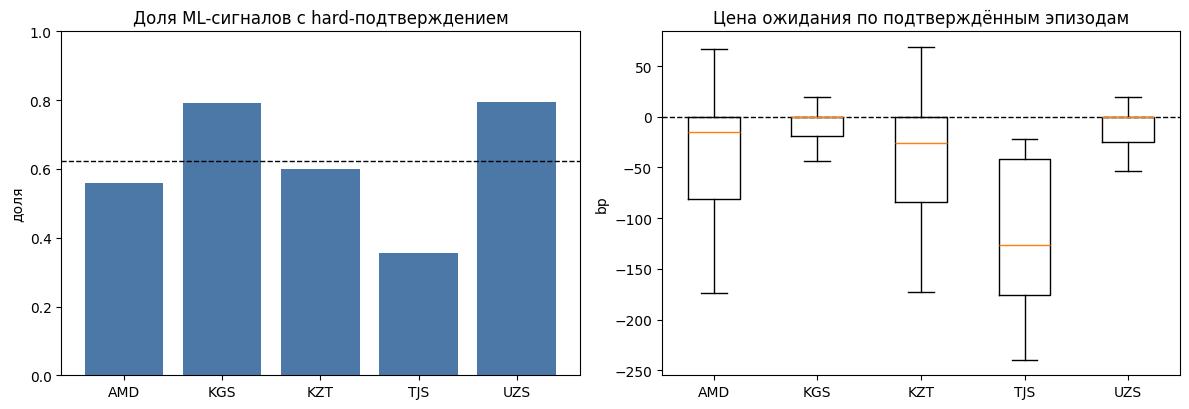

In [3]:
confirmed = pairs[pairs['confirmed']].copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(waiting['currency'], waiting['confirmation_rate'], color='#4C78A8')
axes[0].set(title='Доля ML-сигналов с hard-подтверждением', ylabel='доля', ylim=(0, 1))
axes[0].axhline(waiting['confirmed_signals'].sum() / waiting['ml_signals'].sum(),
                color='black', linestyle='--', linewidth=1)
axes[1].boxplot(
    [confirmed.loc[confirmed['currency'].eq(c), 'waiting_cost_bps'] for c in waiting['currency']],
    tick_labels=waiting['currency'], showfliers=False,
)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set(title='Цена ожидания по подтверждённым эпизодам', ylabel='bp')
plt.tight_layout()
plt.show()

## 2. Что происходит с итоговыми метриками

In [4]:
comparison_table = comparison[[
    'horizon', 'policy', 'mean_truth_lift', 'min_truth_lift',
    'mean_benefit_bps', 'min_benefit_bps', 'median_signals_per_week',
]].replace({'policy': {
    'send_immediately': 'отправить сразу',
    'wait_for_hard_confirmation': 'ждать hard-подтверждение',
}}).rename(columns={
    'horizon': 'h', 'policy': 'политика',
    'mean_truth_lift': 'средний lift', 'min_truth_lift': 'минимальный lift',
    'mean_benefit_bps': 'средняя выгода, bp',
    'min_benefit_bps': 'минимальная выгода, bp',
    'median_signals_per_week': 'медианная частота/нед.',
})
display(comparison_table.round(3))

,h,политика,средний lift,минимальный lift,"средняя выгода, bp","минимальная выгода, bp",медианная частота/нед.
0,1,отправить сразу,1.152,1.078,6.803,1.279,0.517
1,3,отправить сразу,1.161,1.102,14.008,10.575,0.517
2,5,отправить сразу,1.308,1.260,24.757,21.736,0.517
3,10,отправить сразу,1.481,1.352,51.529,41.435,0.517
4,20,отправить сразу,1.762,1.588,94.814,76.008,0.517
5,1,ждать hard-подтверждение,0.978,0.496,18.539,13.112,0.253
6,3,ждать hard-подтверждение,0.951,0.536,36.775,22.526,0.253
7,5,ждать hard-подтверждение,0.964,0.503,47.918,31.627,0.253
8,10,ждать hard-подтверждение,1.144,0.497,80.565,59.846,0.253
9,20,ждать hard-подтверждение,1.336,0.636,125.330,93.273,0.253


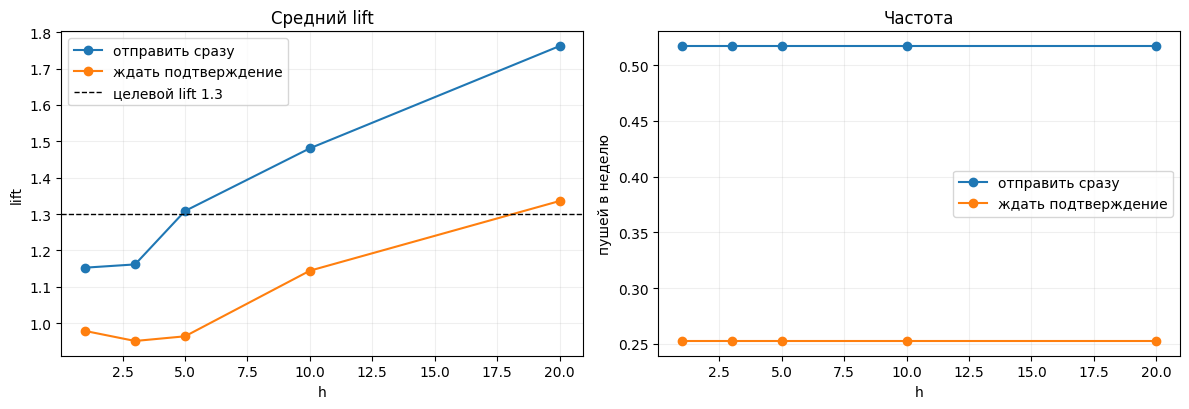

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
labels = {'send_immediately': 'отправить сразу',
          'wait_for_hard_confirmation': 'ждать подтверждение'}
for policy_name, group in comparison.groupby('policy'):
    group = group.sort_values('horizon')
    axes[0].plot(group['horizon'], group['mean_truth_lift'], marker='o',
                 label=labels[policy_name])
    axes[1].plot(group['horizon'], group['median_signals_per_week'], marker='o',
                 label=labels[policy_name])
axes[0].axhline(1.3, color='black', linestyle='--', linewidth=1, label='целевой lift 1.3')
axes[0].set(title='Средний lift', xlabel='h', ylabel='lift')
axes[1].set(title='Частота', xlabel='h', ylabel='пушей в неделю')
for ax in axes:
    ax.legend(loc='best')
    ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

## 3. Численный вывод и правило для пилота

In [6]:
total_ml = int(waiting['ml_signals'].sum())
total_confirmed = int(waiting['confirmed_signals'].sum())
confirmation_rate = total_confirmed / total_ml
median_delay = confirmed['delay_observations'].median()
p90_delay = confirmed['delay_observations'].quantile(.90)
mean_cost = confirmed['waiting_cost_bps'].mean()

def row(policy_name, h):
    return comparison.loc[
        comparison['policy'].eq(policy_name) & comparison['horizon'].eq(h)
    ].iloc[0]

fast5, slow5 = row('send_immediately', 5), row('wait_for_hard_confirmation', 5)
fast10, slow10 = row('send_immediately', 10), row('wait_for_hard_confirmation', 10)

display(Markdown(f"""Hard-подтверждение появляется у **{total_confirmed} из {total_ml}**
ML-сигналов ({confirmation_rate:.1%}); медианная задержка — **{median_delay:.0f}**
публикация, p90 — **{p90_delay:.0f}**. На подтверждённых эпизодах средняя цена
ожидания равна **{mean_cost:+.1f} bp**.

При этом официальный lift ухудшается: на $h=5$ с **{fast5.mean_truth_lift:.3f}**
до **{slow5.mean_truth_lift:.3f}**, на $h=10$ с **{fast10.mean_truth_lift:.3f}**
до **{slow10.mean_truth_lift:.3f}**. Минимальный валютный lift на $h=10$ падает
с **{fast10.min_truth_lift:.3f}** до **{slow10.min_truth_lift:.3f}**, а медианная
частота — с **{fast10.median_signals_per_week:.3f}** до
**{slow10.median_signals_per_week:.3f}** пуша в неделю.

Hard-подтверждение часто возникает во время продолжающегося снижения: цена в
момент подтверждения лучше, но после неё нередко становится ещё ниже. Поэтому
оно улучшает цену входа среди подтверждённых случаев, но ухудшает правдивость
утверждения «сейчас выгодно» и отбрасывает часть ML-сигналов.

**Правило для пилота:** ML-пуш отправляется сразу. Будущий hard-сигнал не служит
gate. Если разрешённый hard-факт уже наблюдается в дату ML-сигнала, он может
использоваться как объяснение в тексте сообщения."""))

Hard-подтверждение появляется у **125 из 201**
ML-сигналов (62.2%); медианная задержка — **1**
публикация, p90 — **4**. На подтверждённых эпизодах средняя цена
ожидания равна **-41.6 bp**.

При этом официальный lift ухудшается: на $h=5$ с **1.308**
до **0.964**, на $h=10$ с **1.481**
до **1.144**. Минимальный валютный lift на $h=10$ падает
с **1.352** до **0.497**, а медианная
частота — с **0.517** до
**0.253** пуша в неделю.

Hard-подтверждение часто возникает во время продолжающегося снижения: цена в
момент подтверждения лучше, но после неё нередко становится ещё ниже. Поэтому
оно улучшает цену входа среди подтверждённых случаев, но ухудшает правдивость
утверждения «сейчас выгодно» и отбрасывает часть ML-сигналов.

**Правило для пилота:** ML-пуш отправляется сразу. Будущий hard-сигнал не служит
gate. Если разрешённый hard-факт уже наблюдается в дату ML-сигнала, он может
использоваться как объяснение в тексте сообщения.